In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
!pip install langchain langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 3.3 MB/s eta 0:00:00


In [2]:
%cd /content/drive/MyDrive/Colab Notebooks/인사교1_LangChain_20260624

/content/drive/MyDrive/Colab Notebooks/인사교1_LangChain_20260624


In [3]:
import os

In [4]:
with open("./key/openai_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['OPENAI_API_KEY'] = api_key

### 생활정보를 알려주는 챗봇을 만들어보자

In [8]:
# 모델생성 함수
from langchain.chat_models import init_chat_model
# 프롬프트 템플릿 도구
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
# 출력파서 도구
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
# 조건분기 및 병령실행 도구
from langchain_core.runnables import RunnableBranch, RunnableParallel

#### 1\. 요구사항 정보 추출

In [9]:
# 모델생성
llm = init_chat_model(model="openai:gpt-4o-mini", max_tokens=1024, temperature=0)

In [10]:
# 분류용 템플릿
classify_template = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        넌 생활정보를 제공하는 챗봇이야.
        아래 question을 보고 어떤 요청인지 날씨/음식/기타 3가지 중에 분류해줘.
        출력형식은 날씨 or 음식 처럼 분류된 카테고리 키워드만 나오게 해줘
        """
    ),
    ('human', "question : {question}")
])

In [12]:
# 지역정보 추출용 템플릿
location_template = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        넌 생활정보를 제공하는 챗봇이야.
        아래 question을 보고 지역정보를 추출해줘.
        출력형식은 광주 or 대전처럼 지역명만 나오게 해줘.
        만약 지역정보가 없으면 없음 이라는 키워드로 처리해줘
        """
    ),
    ("human", "question : {question}")
])

In [14]:
# 체인구성 및 테스트
extract_info_chain = RunnableParallel(
    {
        "request_type" : classify_template | llm | StrOutputParser(),
        'location' : location_template | llm | StrOutputParser()
    }
)

In [15]:
extract_info_chain.invoke("광주지역 날씨 알려줘")

{'request_type': '날씨', 'location': '광주'}

In [16]:
extract_info_chain.invoke("우산 가져갈까?")

{'request_type': '날씨', 'location': '없음'}

#### 2\. Task에 따른 외부정보 확보(분기)

In [17]:
# 실제로는 외부 API를 호출하는 함수로 구성하면 됨
# 학습을 위해 딕셔너리에서 반환하도록 구성
def get_weather(city):
    weather_data = {
        "서울": "비가 오고 있습니다. 기온은 22도입니다.",
        "부산": "맑습니다. 기온은 26도입니다.",
        "광주": "흐립니다. 기온은 24도입니다.",
        "대전": "소나기가 내리고 있습니다. 기온은 23도입니다."
    }

    return weather_data.get(city, f"{city}의 날씨 정보는 준비되어 있지 않습니다.")


def get_restaurant(city):
    restaurant_data = {
        "서울": "서울에는 김치찌개와 삼겹살 맛집이 많습니다.",
        "부산": "부산에는 돼지국밥과 회 맛집이 유명합니다.",
        "광주": "광주에는 한정식과 떡갈비 맛집이 많습니다.",
        "대전": "대전에는 칼국수 맛집이 많습니다."
    }

    return restaurant_data.get(city, f"{city}의 음식 정보는 준비되어 있지 않습니다.")

In [18]:
# 조건분기 branch 구성
select_tool_chain = RunnableBranch(
    (lambda x: x['request_type'] == '날씨', lambda x : get_weather(x['location'])),
    (lambda x: x['request_type'] == '음식', lambda x : get_restaurant(x['location'])),
    lambda x : "지원하지 않는 요청사항입니다."
)

In [19]:
# 두 확인 연결하기
marge_chain = extract_info_chain | select_tool_chain

In [20]:
marge_chain.invoke("광주 날씨 알려줘")

'흐립니다. 기온은 24도입니다.'

In [21]:
marge_chain.invoke("오늘 우산 가져갈까?")

'없음의 날씨 정보는 준비되어 있지 않습니다.'

In [22]:
marge_chain.invoke("부산에서 유명한 음식 알려줘")

'부산에는 돼지국밥과 회 맛집이 유명합니다.'

#### 3\. 출력메세지 보정하기

In [27]:
response_msg_template = ChatPromptTemplate.from_messages([
    (
        'system',
        '''
            너는 사용자의 질문에 따라 생활정보를 제공하는 챗봇이야.
            앞에 chain에 나온 결과를 사용자에게 자연스럽게 전달할 수 있게변경해줘
            불필요한 정보나 맥락을추가하지마. 문장길이는 5줄 이내로 구성해줘.
        '''
    ),
    ('ai', '{msg}')
])

In [30]:
# 최종체인 구성하기
living_info_chain = {'msg' : marge_chain} | response_msg_template | llm | StrOutputParser()

In [31]:
living_info_chain.invoke("광주 날씨 알려줘")

'현재 날씨는 흐리고 기온은 24도입니다. 추가로 궁금한 점이 있으면 말씀해 주세요.'

In [32]:
living_info_chain.invoke("오늘 우산 챙길까?")

'현재 날씨 정보는 제공되지 않습니다. 다른 질문이 있으시면 말씀해 주세요.'

In [33]:
living_info_chain.invoke("부산 맛집")

'부산에서는 돼지국밥과 신선한 회가 특히 유명해요. 맛집을 찾으신다면 이 두 가지를 꼭 추천드립니다.'

### Agent 구성하기

In [34]:
from langchain.agents import create_agent   # 에이전트를 생성하는 함수
from langchain.tools import tool            # 에이전트가 스스로 선택하는 도구

In [39]:
# @tool을 이용해 함수를 에이전트가 사용할 도구로 인식
# doc string을 이용해 도구가 어떤 의미인지 파악하도록 함
@tool
def get_weather(city : str) -> str :
    """입력된 도시의 현재 날씨 정보를 반환합니다."""
    weather_data = {
        "서울": "비가 오고 있습니다. 기온은 22도입니다.",
        "부산": "맑습니다. 기온은 26도입니다.",
        "광주": "흐립니다. 기온은 24도입니다.",
        "대전": "소나기가 내리고 있습니다. 기온은 23도입니다."
    }

    return weather_data.get(city, f"{city}의 날씨 정보는 준비되어 있지 않습니다.")

@tool
def get_restaurant(city : str) -> str :
    """입력된 도시의 유명한 음식점 정보를 반환합니다."""
    restaurant_data = {
        "서울": "서울에는 김치찌개와 삼겹살 맛집이 많습니다.",
        "부산": "부산에는 돼지국밥과 회 맛집이 유명합니다.",
        "광주": "광주에는 한정식과 떡갈비 맛집이 많습니다.",
        "대전": "대전에는 칼국수 맛집이 많습니다."
    }

    return restaurant_data.get(city, f"{city}의 음식 정보는 준비되어 있지 않습니다.")

In [40]:
# 테스트
llm_with_tools = llm.bind_tools([get_weather, get_restaurant])

In [41]:
# 어떤 도구를 호출하면 되는지 판단 -> 실행 X
llm_with_tools.invoke("광주 날씨 알려줘")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 81, 'total_tokens': 96, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b4b9deb02a', 'id': 'chatcmpl-Dx1Bo4DQu1NS9qmBl1fMiXgLZzppe', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f2098-8c64-76b1-870b-50d3af2859ae-0', tool_calls=[{'name': 'get_weather', 'args': {'city': '광주'}, 'id': 'call_fyAU8YE9UwKPzeKPEVt7XFwa', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 81, 'output_tokens': 15, 'total_tokens': 96, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [42]:
# agent 생성
agent = create_agent(
    # agent 판단 주체가되는 모델 연결
    model = llm,
    # agent가 스스로 판단해서 사용할 도구 목록
    tools = [get_weather, get_restaurant],
    system_prompt = "너는 생활 정보를 알려주는 도우미 assistant야"
)

In [50]:
# agent 구조 확인
from IPython.display import Image, display

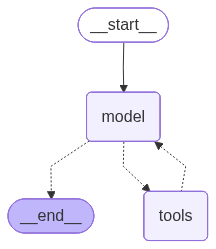

In [51]:
display(Image(agent.get_graph().draw_mermaid_png()))

In [52]:
# agent 호출
rs = agent.invoke(
    {"messages": [
            {"role": "user", "content": "광주에서 뭘 먹으면 좋을까?"}
    ]}
)

In [57]:
rs['messages'][-1].content

'광주에서는 한정식과 떡갈비를 추천합니다. 다양한 반찬과 함께 즐길 수 있는 한정식과, 맛있는 떡갈비를 꼭 맛보세요!'